## save

In [14]:
import numpy as np
import pandas as pd
from sympy import limit
import wandb

LIMIT = 1000

api = wandb.Api(
    api_key="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",
    timeout=60
)

# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    filters={
        # "display_name": {"$regex": "trained_on_.._eval_on_.._..?_shot_.+"},
        # "config.dataset": "ukr_rus_twitter",
        # "config.task_name": "neighbor_matching",
    },
    order="-created_at",
    per_page=LIMIT,
    # limit to 10:
    lazy=False
)

In [32]:
runs[0].config['params']['root'], runs[0].config['params']['graph_filename']

('/scratch1/eibl/data/election2020/graphs', 'retweet_graph.pt')

In [35]:
rows = []
for run in runs[:LIMIT]:
    attrs = getattr(run, "_attrs", {}) or {}
    params = ((attrs.get("config") or {}).get("params") or {})
    summary = attrs.get("summaryMetrics") or {}

    rows.append({
        "run_id": attrs.get("name"),
        "display_name": attrs.get("displayName"),
        "state": attrs.get("state"),
        "dataset": params.get("dataset"),
        "task_name": params.get("task_name"),
        "prefix": params.get("prefix"),
        "pretrained_model_run": params.get("pretrained_model_run"),
        "n_shots": params.get("n_shots"),
        "n_way": params.get("n_way"),
        "n_query": params.get("n_query"),
        "zero_shot": params.get("zero_shot"),
        "test_accuracy": summary.get("test_accuracy"),
        "train_accuracy": summary.get("train_accuracy"),
        "test_f1": summary.get("test_f1"),
        "test_roc_auc": summary.get("test_roc_auc"),
        "created_at": attrs.get("createdAt"),
        'steps': attrs['historyKeys']['keys'].get('_step', {}).get('typeCounts', [{}])[0].get('count', np.nan),
        'tags': attrs.get("tags", []),
        'input_dim': params.get("input_dim"),
        'graph': params.get('root', 'nan') + "/" + params.get('graph_filename', 'nan')
    })
df = pd.DataFrame(rows)
df["task_name"] = df["task_name"].map({
    "neighbor_matching": "nm",
    "temporal_link_prediction": "lp",
    "classification": "pl",
})
df['created_at'] = pd.to_datetime(df['created_at'])
df["shot_label"] = df.apply(lambda r: 0 if bool(r.get("zero_shot", False)) else r["n_shots"], axis=1)
# df['is_eval'] = df['display_name'].str.contains(r"eval")
# plot_df = df[df["eval1_task"].isin(EVAL_TASKS) & df["train1_task"].eq("nm")].copy()
df['eval1_dataset'] = df['dataset']
df['trained_on_display_name'] = df.pretrained_model_run.str.findall("(.+)/(.+)/((checkpoint/(.+)\.ckpt)|state_dict)$").str[0].str[1]
df['month/day'] = df['created_at'].dt.month.astype(str) + '/' + df['created_at'].dt.day.astype(str)
df = df.sort_values('created_at', ascending=False)
mask = df['trained_on_display_name'].isin(df['display_name'])
existing_trained_on_display_names = df.trained_on_display_name[mask]
df__ = df.copy()

In [ ]:
exp_df = df__[df__.display_name.str.contains("(interaction|retweet)(.*)250k")]
exp_df['graph_type'] = exp_df.display_name.str.findall("(interaction|retweet)(.*)250k").str[0].str[0]
exp_df['input_feature_type'] = exp_df.display_name.str.findall("(interaction|retweet)(.*)250k_(all|constant1|stats_only|emb_only|minilm)").str[0].str[-1]
exp_df['input_feature_type'] = exp_df['input_feature_type'].fillna('emb_only')

assert exp_df[exp_df.input_feature_type == 'constant1'].input_dim.eq(1).all()
assert exp_df[exp_df.input_feature_type == 'stats_only'].input_dim.eq(11).all()
assert exp_df[exp_df.input_feature_type == 'emb_only'].input_dim.eq(384).all()
assert exp_df[exp_df.input_feature_type == 'all'].input_dim.eq(395).all()

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_15657/3389892550.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  exp_df = df__[df__.display_name.str.contains("(interaction|retweet)(.*)250k")]


In [48]:
exp_df.to_csv("exp_df.csv", index=False)

## process

In [49]:
import pandas as pd
exp_df = pd.read_csv("exp_df.csv", index_col=None)

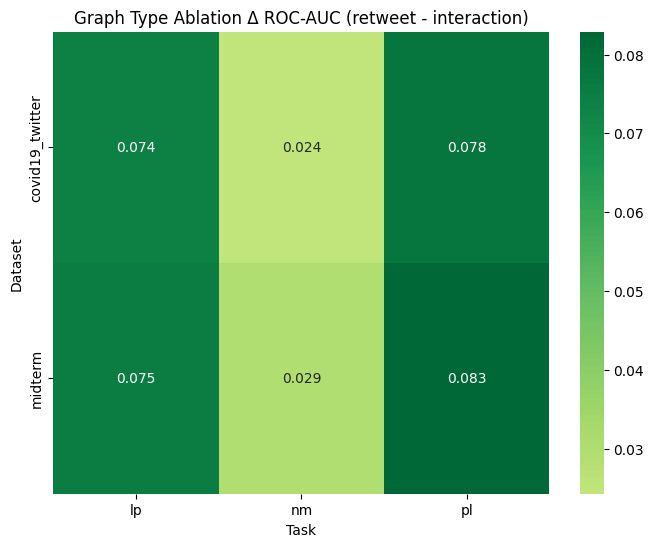

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# average in case multiple runs exist
graph_ablation = (
    exp_df.groupby(["dataset", "task_name", "graph_type"])["test_roc_auc"]
    .mean()
    .reset_index()
)

# make graph types columns
pivot = graph_ablation.pivot_table(
    index=["dataset", "task_name"],
    columns="graph_type",
    values="test_roc_auc"
)

# compute delta
# adjust names if your graph types differ
pivot["delta"] = pivot["retweet"] - pivot["interaction"]

# reshape for heatmap
delta_heatmap = pivot["delta"].unstack("task_name")

plt.figure(figsize=(8,6))
sns.heatmap(
    delta_heatmap,
    annot=True,
    cmap="RdYlGn",
    # vmin=0, vmax=0.2,
    center=0,     # important: zero becomes neutral
    fmt=".3f"
)

plt.title("Graph Type Ablation Δ ROC-AUC (retweet - interaction)")
plt.ylabel("Dataset")
plt.xlabel("Task")
plt.show()

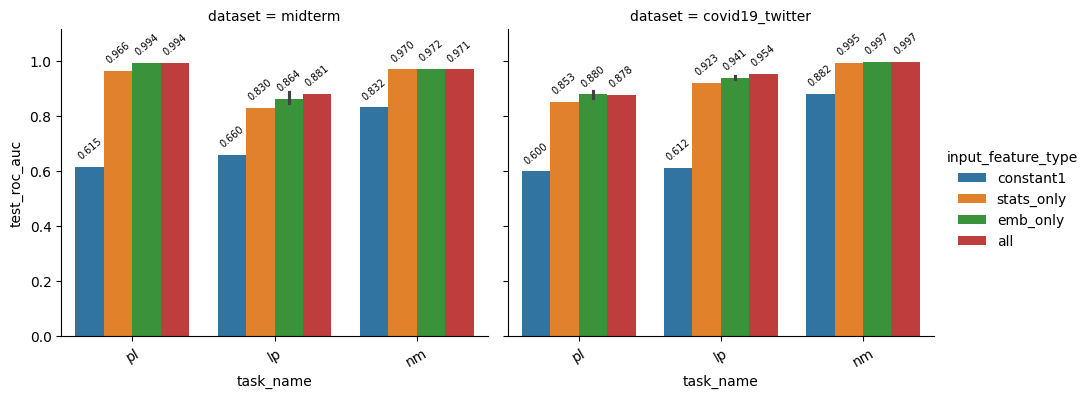

In [74]:
g = sns.catplot(
    data=exp_df,
    x="task_name",
    y="test_roc_auc",
    hue="input_feature_type",
    col="dataset",
    kind="bar",
    height=4,
    aspect=1.2
)

for ax in g.axes.flat:
    ax.set_ylim(0, exp_df["test_roc_auc"].max() * 1.12)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=4,
            fontsize=7,
            rotation=40
        )

    ax.tick_params(axis="x", rotation=30)

plt.show()

In [54]:
# exp_df[['input_feature_type']]
cols = ['dataset', 'task_name', 'input_feature_type', 'test_roc_auc']
exp_df[exp_df.graph_type.eq('interaction')][cols].sort_values(cols)

,dataset,task_name,input_feature_type,test_roc_auc
12,covid19_twitter,lp,all,0.954447
30,covid19_twitter,lp,constant1,0.611828
29,covid19_twitter,lp,emb_only,0.937384
1,covid19_twitter,lp,emb_only,0.939166
22,covid19_twitter,lp,stats_only,0.922590
33,covid19_twitter,nm,all,0.996789
21,covid19_twitter,nm,constant1,0.881542
2,covid19_twitter,nm,emb_only,0.996057
26,covid19_twitter,nm,emb_only,0.996649
16,covid19_twitter,nm,stats_only,0.995303
